_# Ordinal Data
Feature reduction, redundancy and feature engineering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

data = pd.read_csv("Data/ordinal_train_cleaned.csv")
X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

X

,OverallQual,OverallQual.1,OverallCond,MSSubClass,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,...,HeatingQC,KitchenQual,FireplaceQu,GarageFinish,GarageQual,GarageCond,LotShape,LandSlope,LandContour,SaleCondition
0,7,7,5,60,4,3,4,3,1,6,...,5,4,4,2,3,3,3,2,3,4
1,6,6,8,20,3,3,4,3,4,5,...,5,3,3,2,3,3,3,2,3,4
2,7,7,5,60,4,3,4,3,2,6,...,5,4,3,2,3,3,2,2,3,4
3,7,7,5,70,3,3,3,4,1,5,...,4,4,4,1,3,3,2,2,3,0
4,8,8,5,60,4,3,4,3,3,6,...,5,4,3,2,3,3,2,2,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,6,5,60,3,3,4,3,1,1,...,5,3,3,2,3,3,3,2,3,4
1408,6,6,6,20,3,3,4,3,1,5,...,3,3,3,1,3,3,3,2,3,4
1409,7,7,9,70,5,4,3,4,1,6,...,5,4,4,2,3,3,3,2,3,4
1410,5,5,6,20,3,3,3,3,2,6,...,4,4,4,1,3,3,3,2,3,4


# Mutual Information Score
as first feature reduction criterion

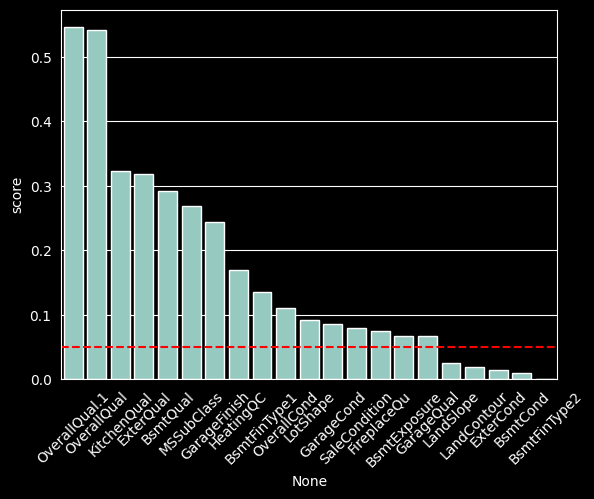

In [3]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns, name='score').sort_values(ascending=False)

sns.barplot(x=mi_series.index, y=mi_series.sort_values(ascending=False))
plt.xticks(rotation=45)
plt.axhline(y=0.05, color='r', linestyle='--')
plt.show()

And We take those having MI score grater than 0.05

In [4]:
selected_X = X[mi_series[mi_series.values > 0.05].keys()]
removed_x = X[mi_series[mi_series.values < 0.05].keys()]

selected_X

,OverallQual.1,OverallQual,KitchenQual,ExterQual,BsmtQual,MSSubClass,GarageFinish,HeatingQC,BsmtFinType1,OverallCond,LotShape,GarageCond,SaleCondition,FireplaceQu,BsmtExposure,GarageQual
0,7,7,4,4,4,60,2,5,6,5,3,3,4,4,1,3
1,6,6,3,3,4,20,2,5,5,8,3,3,4,3,4,3
2,7,7,4,4,4,60,2,5,6,5,2,3,4,3,2,3
3,7,7,4,3,3,70,1,4,5,5,2,3,0,4,1,3
4,8,8,4,4,4,60,2,5,6,5,2,3,4,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,6,3,3,4,60,2,5,1,5,3,3,4,3,1,3
1408,6,6,3,3,4,20,1,3,5,6,3,3,4,3,1,3
1409,7,7,4,5,3,70,2,5,6,9,3,3,4,4,1,3
1410,5,5,4,3,3,20,1,4,6,6,3,3,4,4,2,3


# Vizualizations
with target

## Selected X
to check if categories are correlated with target

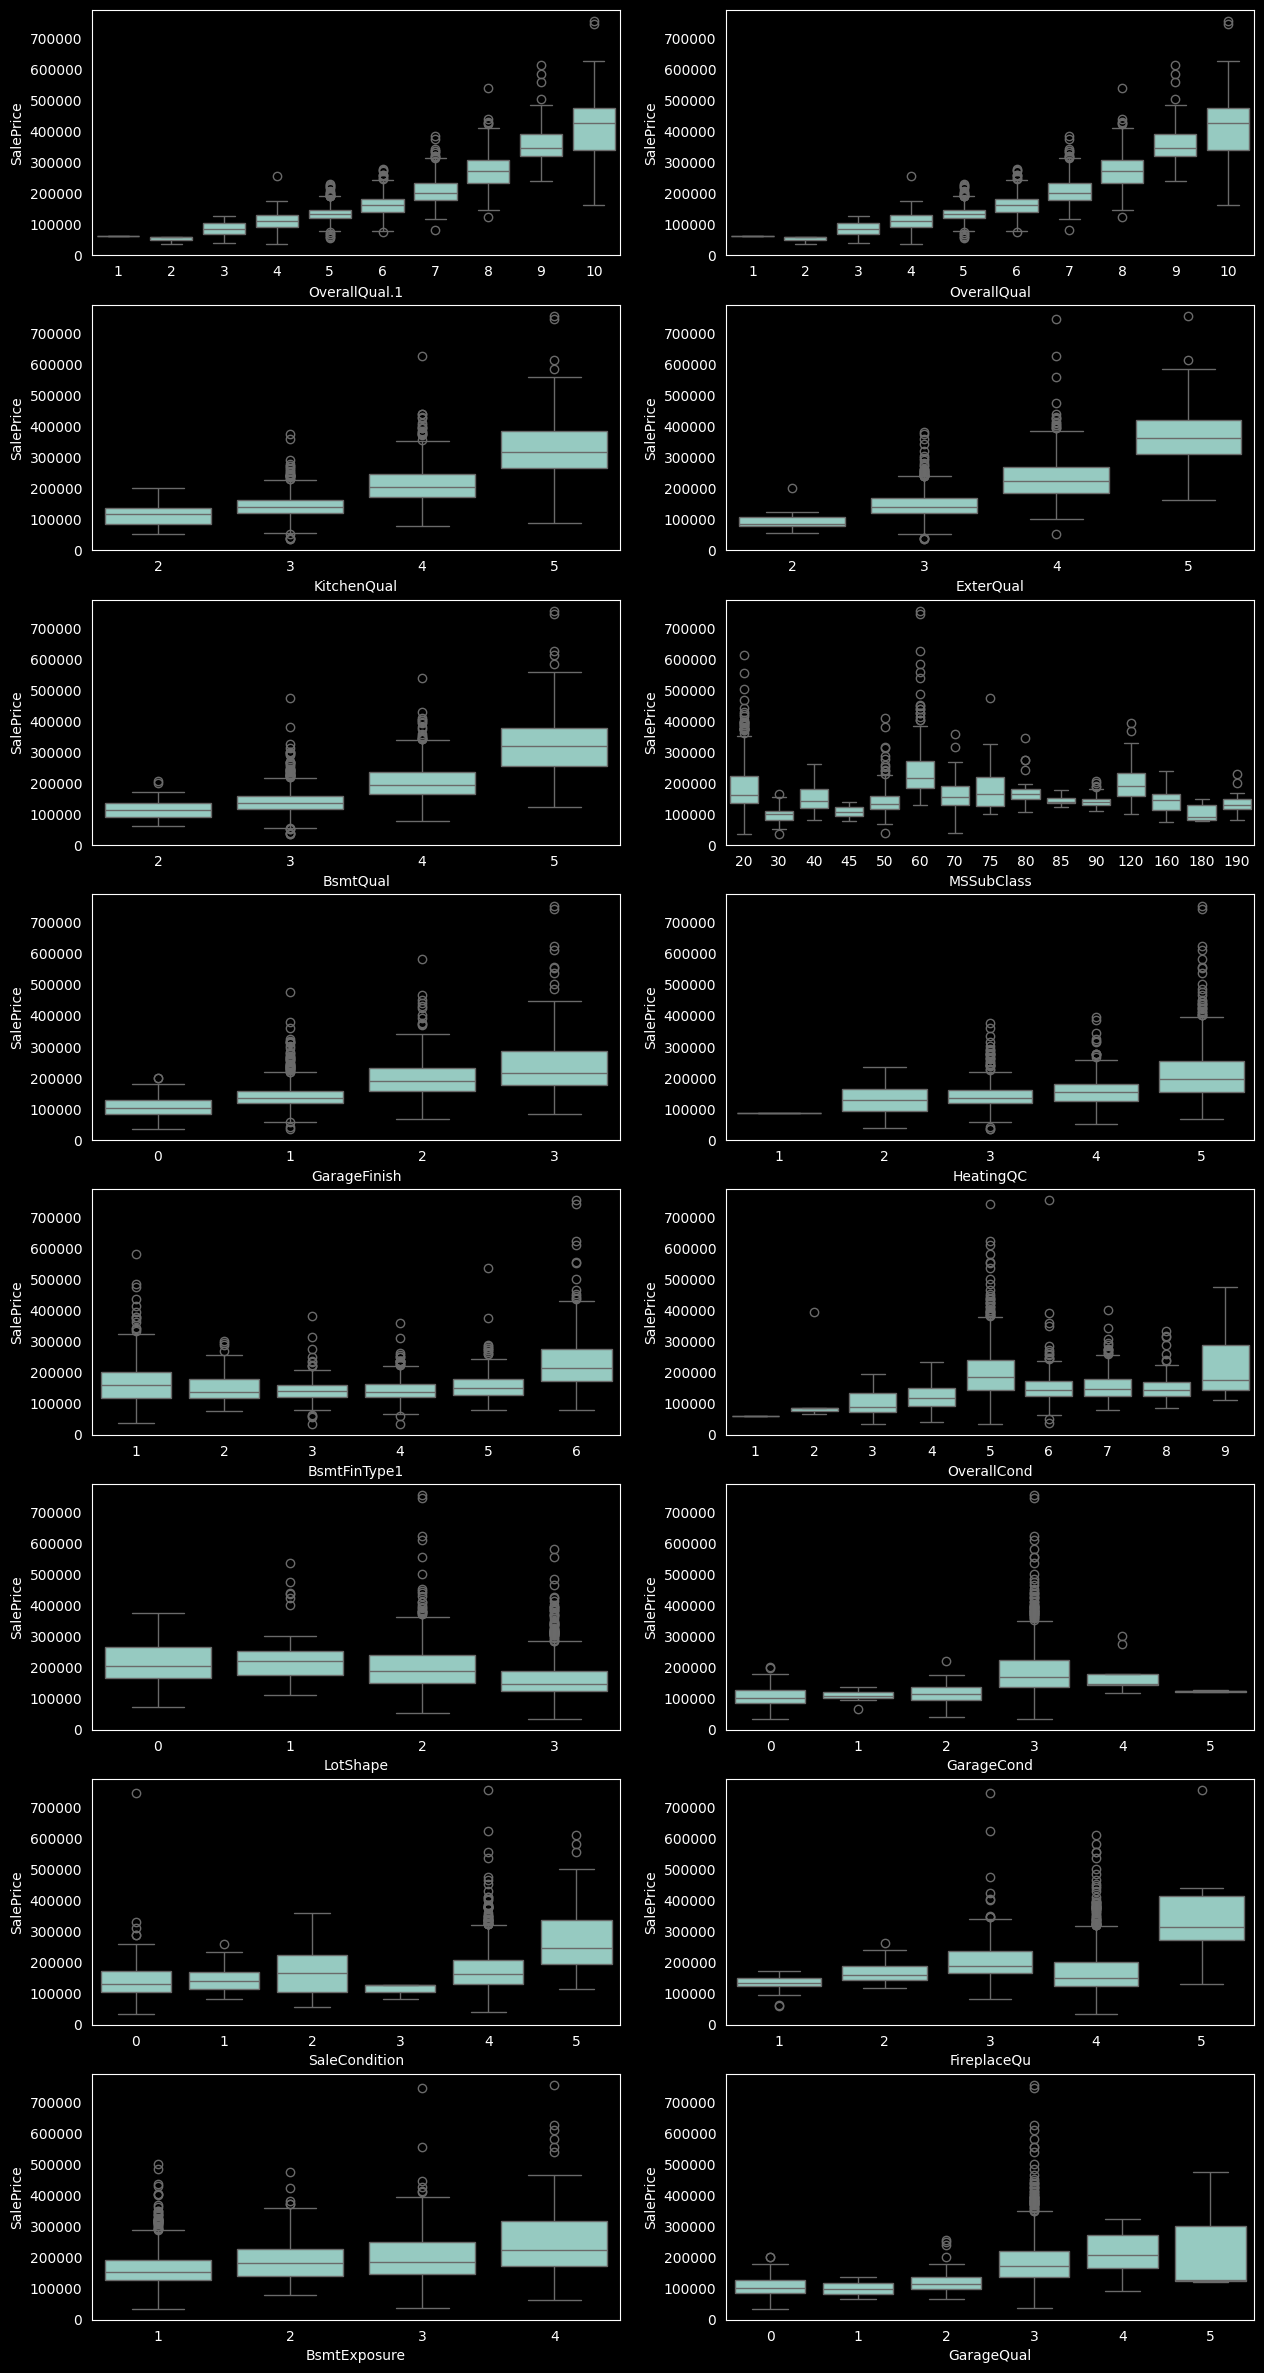

In [5]:
fig, ax = plt.subplots(8,2, figsize=(15,30))
ax = ax.flatten()

for idx, col in enumerate(selected_X.columns):
    sns.boxplot(data=data, x=col, y='SalePrice', ax=ax[idx])
    ax[idx].grid(False)


## Unselected X

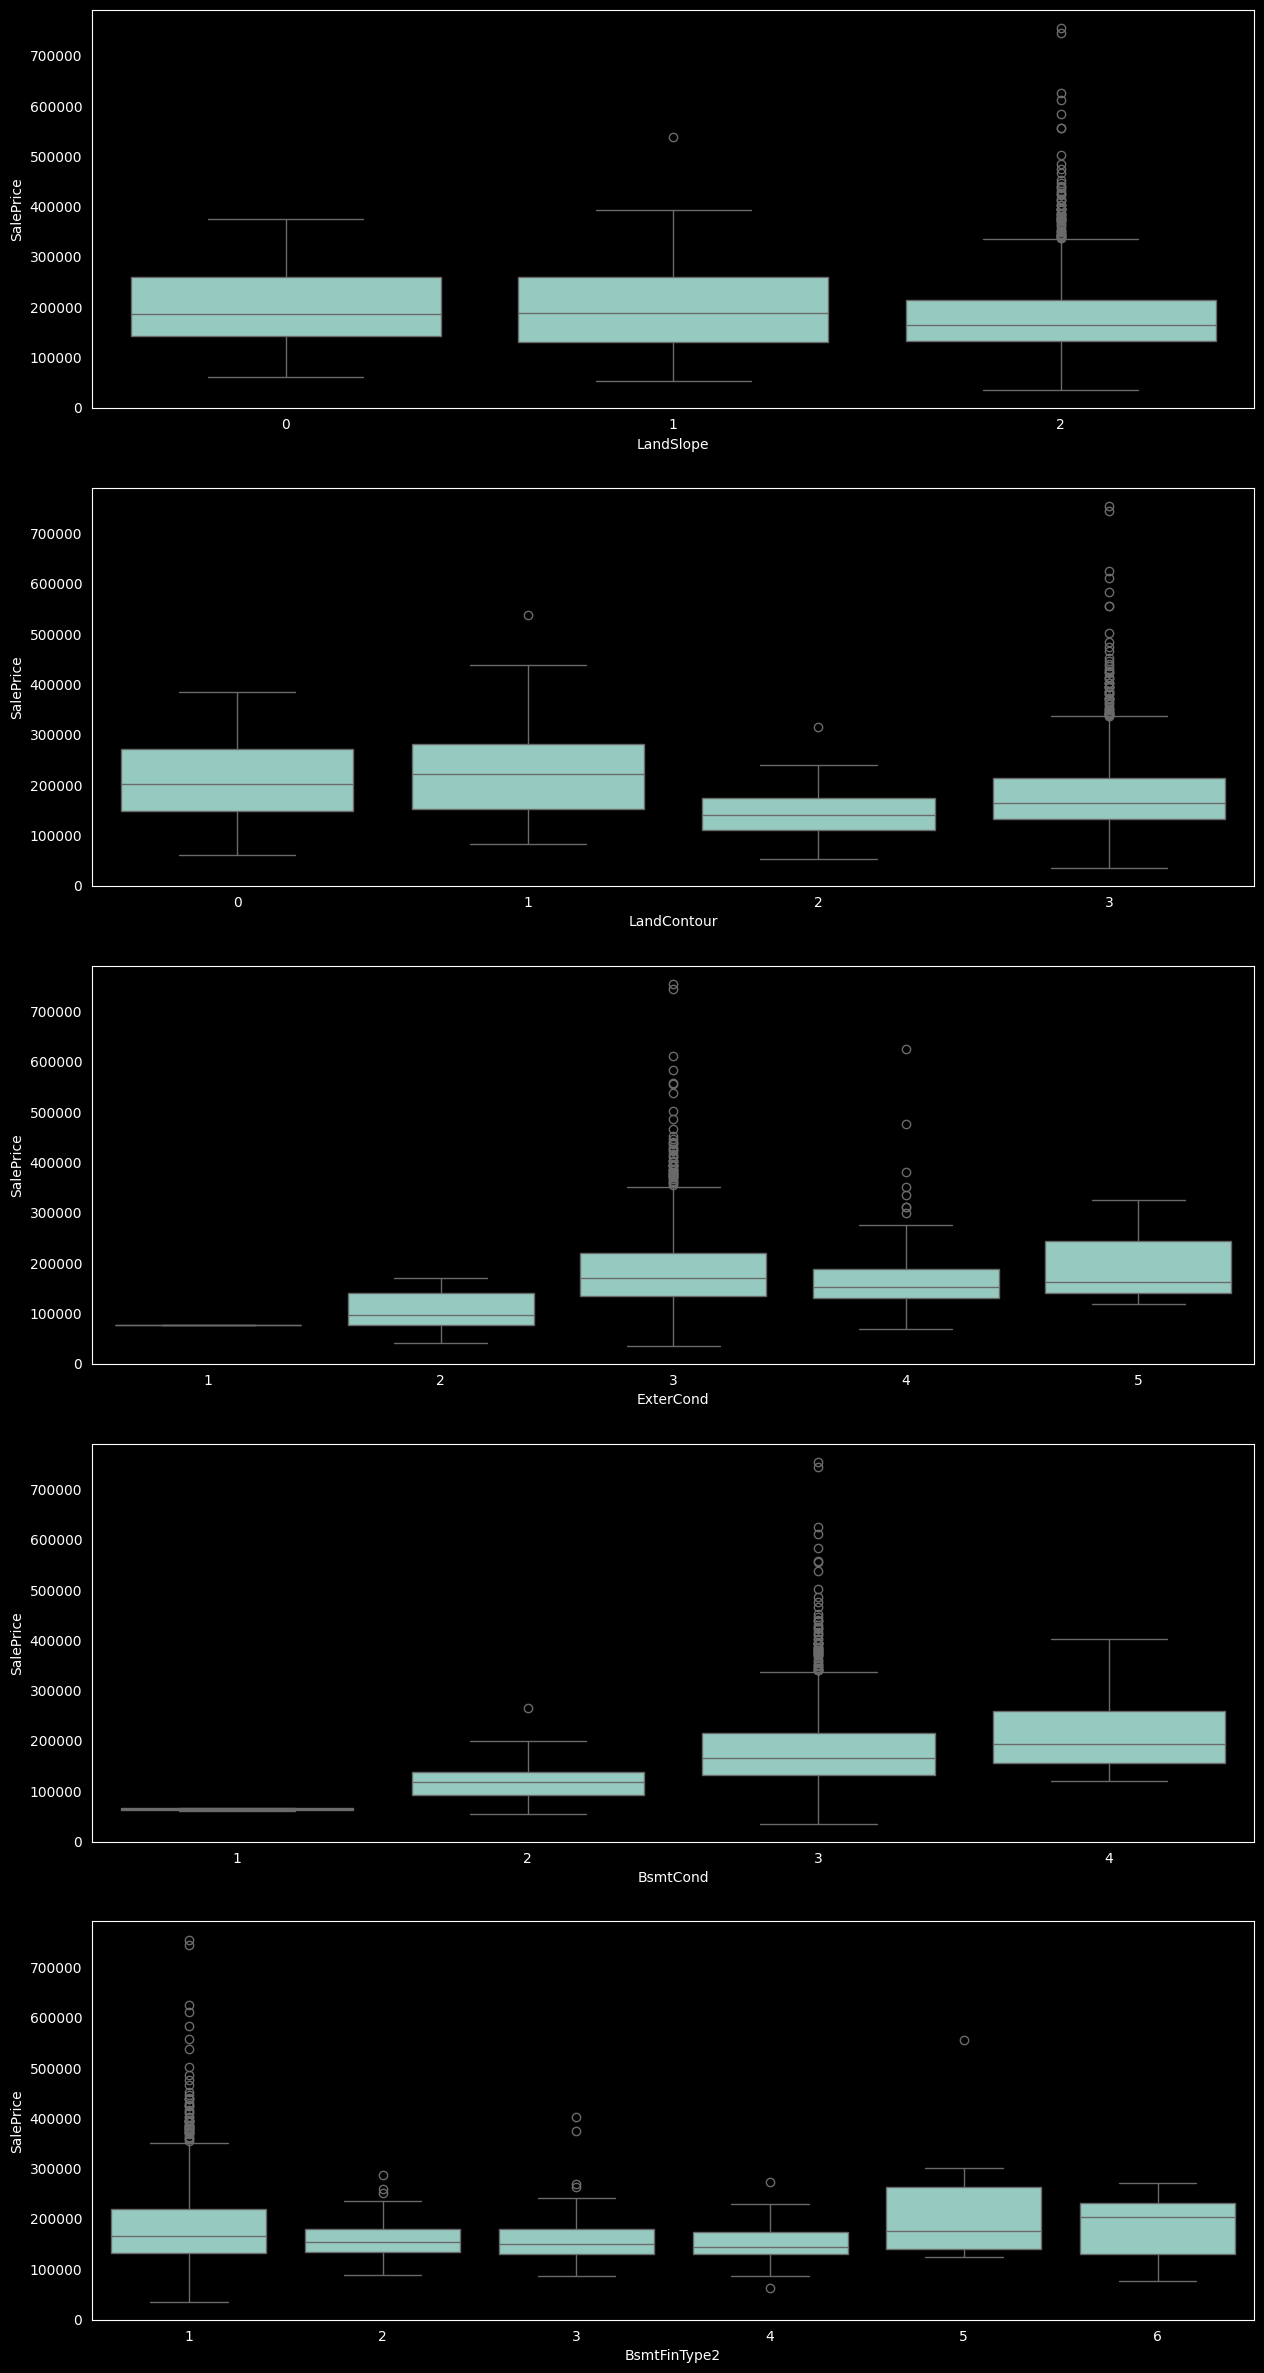

In [6]:
fig, ax = plt.subplots(5,1, figsize=(15,30))
ax = ax.flatten()

for idx, col in enumerate(removed_x.columns):
    sns.boxplot(data=data, x=col, y='SalePrice', ax=ax[idx])
    ax[idx].grid(False)


## Additional reduction
Basing on plots and analyzing correlation with target `BsmtQual` is removed. Rest stays the same.


In [7]:
new_X = selected_X.drop('BsmtQual', axis=1)

##  Correlation

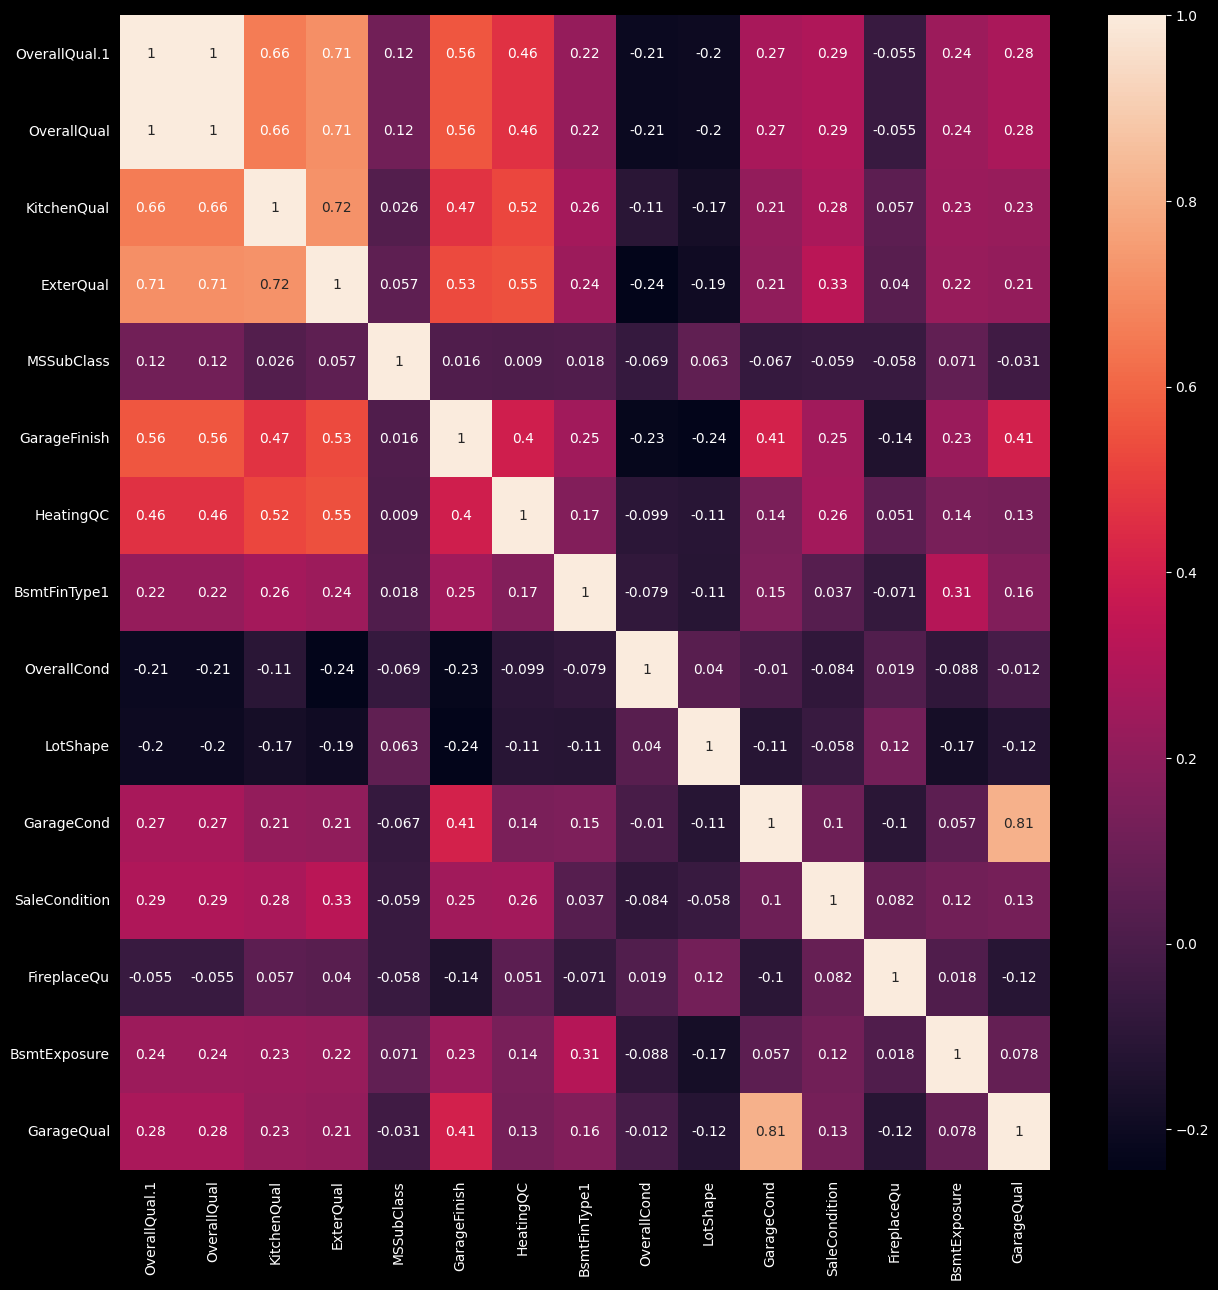

In [8]:
corr_mtx = new_X.corr(method='spearman')

plt.figure(figsize=(15,15))
sns.heatmap(corr_mtx, annot=True)
plt.show()

### Removing highly corralated features

In [9]:
uncor_x = new_X.drop(['OverallQual','GarageCond' ], axis=1)

uncor_x

,OverallQual.1,KitchenQual,ExterQual,MSSubClass,GarageFinish,HeatingQC,BsmtFinType1,OverallCond,LotShape,SaleCondition,FireplaceQu,BsmtExposure,GarageQual
0,7,4,4,60,2,5,6,5,3,4,4,1,3
1,6,3,3,20,2,5,5,8,3,4,3,4,3
2,7,4,4,60,2,5,6,5,2,4,3,2,3
3,7,4,3,70,1,4,5,5,2,0,4,1,3
4,8,4,4,60,2,5,6,5,2,4,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,3,3,60,2,5,1,5,3,4,3,1,3
1408,6,3,3,20,1,3,5,6,3,4,3,1,3
1409,7,4,5,70,2,5,6,9,3,4,4,1,3
1410,5,4,3,20,1,4,6,6,3,4,4,2,3


# PCA Analysis

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def calc_PCA(data):
    pca = PCA(n_components=4)
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    data_scaled = pd.DataFrame(data_scaled, columns=data.columns, index=data.index)
    pca.fit(data_scaled)

    df_components = pd.DataFrame()
    df_PCA = pd.DataFrame(pca.components_.T, index=data_scaled.columns, columns = ['PC1', 'PC2', 'PC3', 'PC4']).sort_values(by='PC1', ascending=False)

    return df_PCA

df_PCA = calc_PCA(uncor_x)
df_PCA

,PC1,PC2,PC3,PC4
ExterQual,0.436460,0.209743,0.031284,-0.030797
OverallQual.1,0.433557,0.109836,0.004825,-0.078699
KitchenQual,0.418106,0.213425,-0.002110,0.068678
GarageFinish,0.388439,-0.219150,-0.108494,-0.224599
HeatingQC,0.330228,0.266557,-0.076821,0.014210
GarageQual,0.223976,-0.324586,-0.364532,-0.277778
BsmtExposure,0.206776,-0.232091,0.438859,0.412951
BsmtFinType1,0.186949,-0.327394,0.341695,0.324423
SaleCondition,0.153968,0.064019,-0.260409,-0.004183
FireplaceQu,0.015513,0.593123,0.061474,0.312283


## Plotting

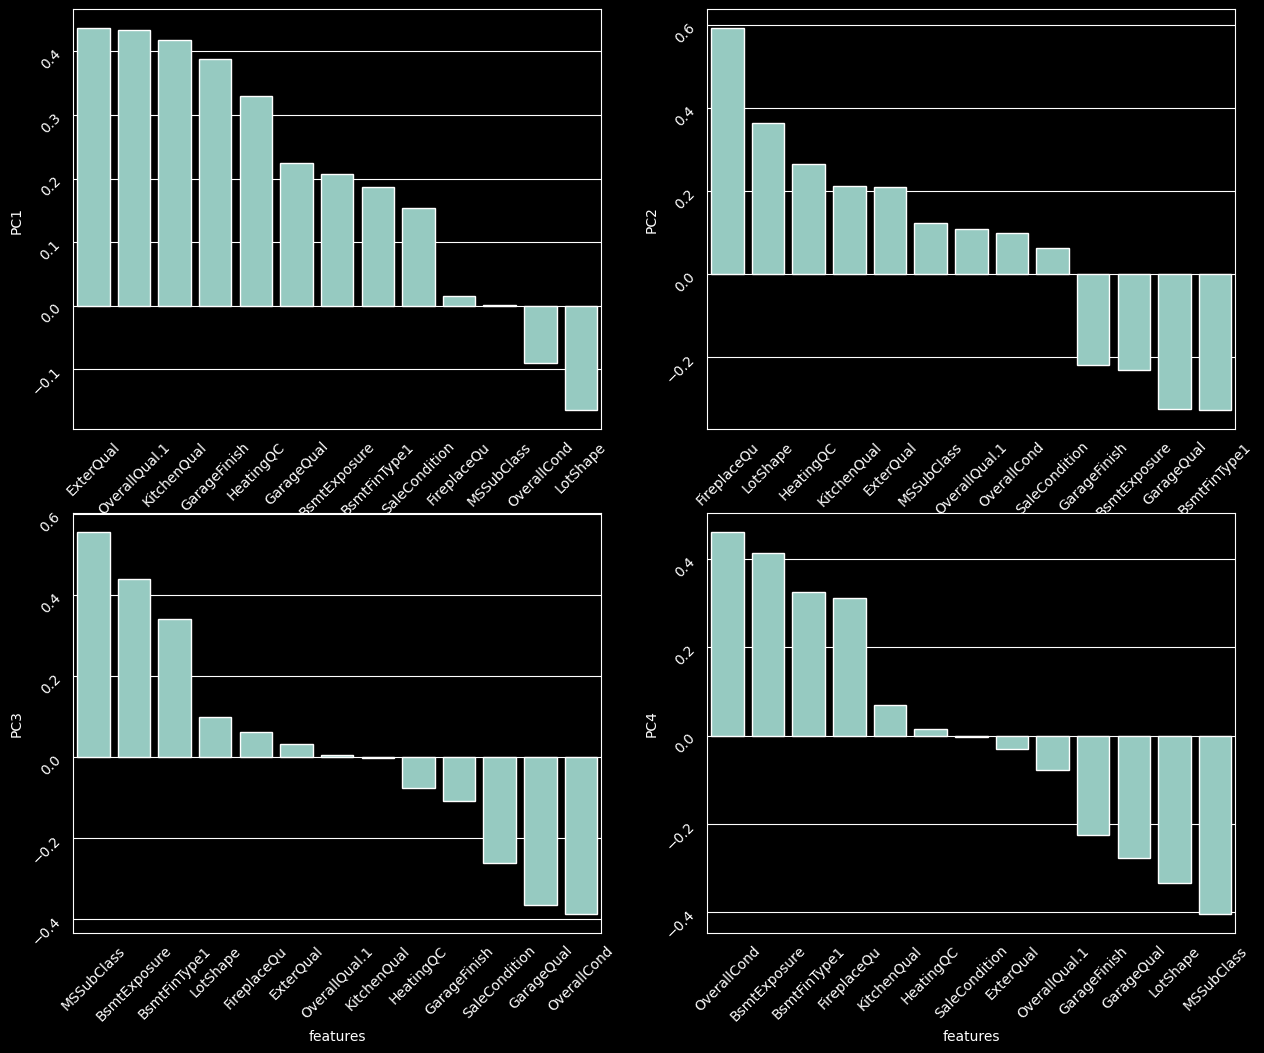

In [12]:
fig, ax = plt.subplots(2,2, figsize = (15,12))
ax=ax.flatten()

for idx, col in enumerate(df_PCA.columns):
    df_PCA.sort_values(by=col, ascending=False, inplace=True)
    sns.barplot(data = df_PCA, x=df_PCA.index, y=col, ax=ax[idx])
    ax[idx].tick_params(rotation=45)
    ax[idx].set_xlabel("features")


plt.show()

# Proposition of new features
Based on PCA and domain Knowledge

In [13]:
def norm(x):
    norm_x = (x - min(x))/(max(x) - min(x))
    return norm_x

final_x = pd.DataFrame()
# Quality
quality_index_col = ['ExterQual', 'OverallQual.1', 'KitchenQual', 'GarageFinish', 'HeatingQC']
final_x['Quality_index'] = uncor_x[quality_index_col].mean(axis=1)

# Basement
final_x['Bsmt_index'] = uncor_x['BsmtExposure'] + uncor_x['BsmtFinType1']

# Garage
final_x['Garage_index'] = uncor_x['GarageQual'] + uncor_x['GarageFinish']

# Condition
final_x['Condition_index'] = norm(uncor_x['OverallCond']) * uncor_x['MSSubClass']


final_x

,Quality_index,Bsmt_index,Garage_index,Condition_index
0,4.4,7,5,30.0
1,3.8,9,5,17.5
2,4.4,8,5,30.0
3,3.8,6,4,35.0
4,4.6,9,5,30.0
...,...,...,...,...
1407,3.8,2,5,30.0
1408,3.2,6,4,12.5
1409,4.6,7,5,70.0
1410,3.4,8,4,12.5


### Check Results

In [19]:
final_x_PCA = calc_PCA(final_x)

for idx, col in enumerate(final_x_PCA.columns):
    df_PCA.sort_values(by=col, ascending=False, inplace=True)
    sns.barplot(data = final_x_PCA, x=final_x_PCA.index, y=col, ax=ax[idx])
    ax[idx].tick_params(rotation=45)
    ax[idx].set_xlabel("features")


final_x_PCA

,PC1,PC2,PC3,PC4
Quality_index,0.645832,0.024267,-0.269414,0.713952
Garage_index,0.634511,-0.098205,-0.326277,-0.693755
Bsmt_index,0.415120,0.315306,0.850890,-0.065141
Condition_index,-0.089288,0.943583,-0.311361,-0.068798


## Scatter Plot to check correlation with Target

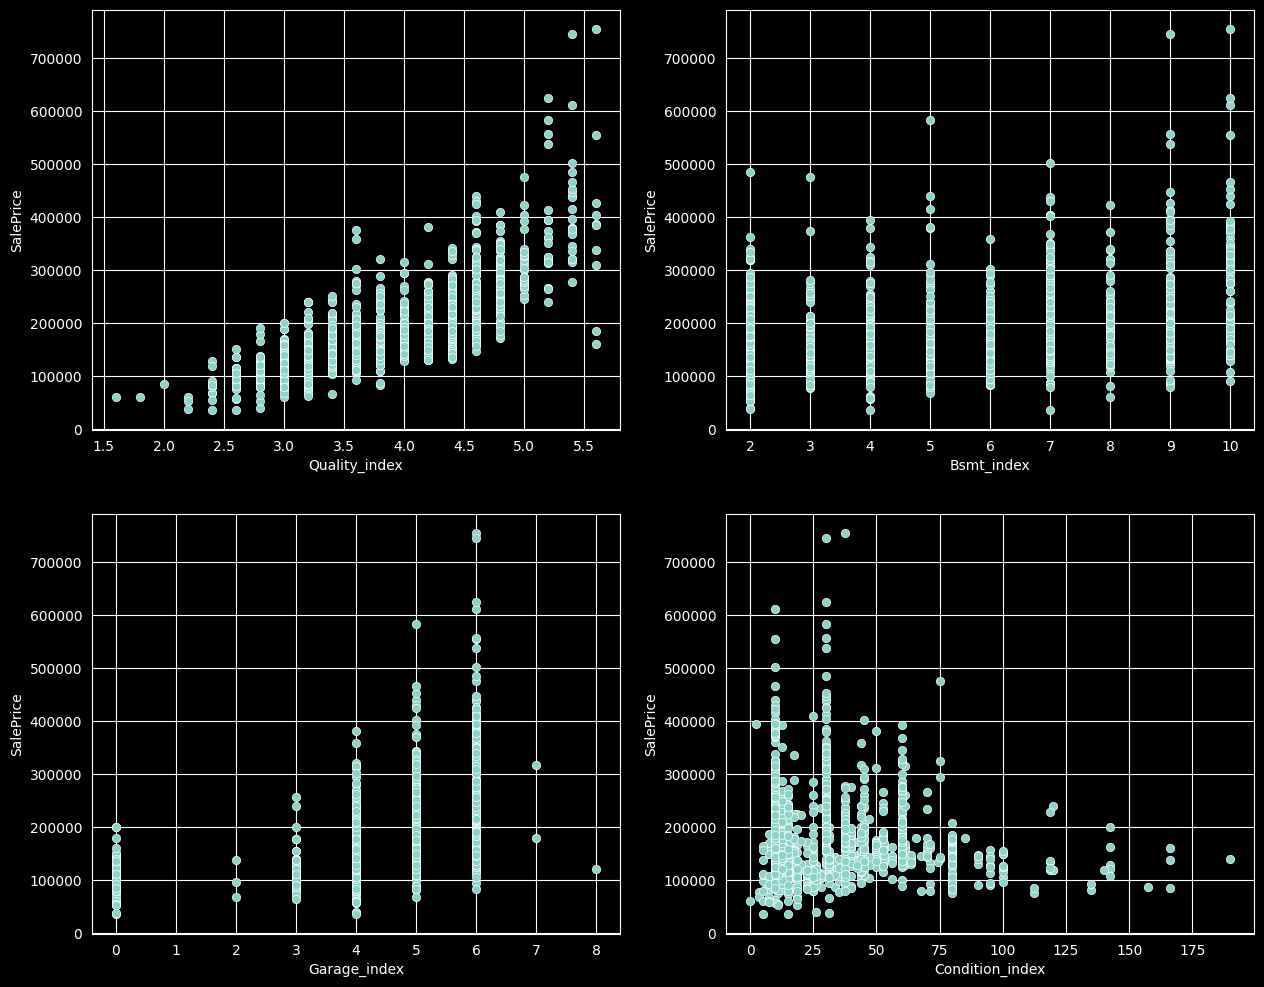

In [22]:
fig, ax = plt.subplots(2,2, figsize = (15,12))
ax=ax.flatten()

for idx, col in enumerate(final_x.columns):
    sns.scatterplot(data=final_x, x=col, y = y, ax=ax[idx])

plt.show()